<a href="https://colab.research.google.com/github/skyish21/AIML-Python/blob/main/DL/%20DL4%20NN%20(MNIST%20using%20TensorFlow).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MNIST Handwritten Digit Classification using Tensorflow

In [127]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

In [128]:
# Loading MNIST Dataset
data = mnist.load_data()

In [129]:
# Already processed data

In [130]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [131]:
type(X_train)

numpy.ndarray

In [132]:
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [133]:
# X train has 60k images and X test has 10k images of 28 x 28 dimension
# Y train and Y test contain corresponding labels, i.e., 0-9 numbers

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

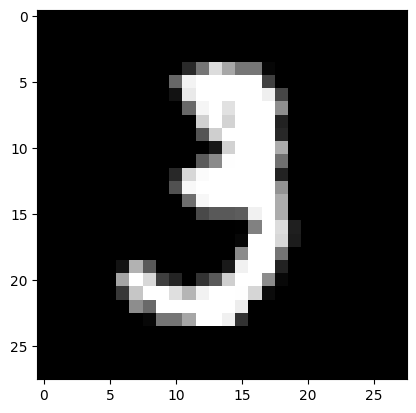

In [134]:
# Print the 10th image
print(X_train[10])
plt.imshow(X_train[10], cmap = 'gray')

In [135]:
print(X_train[10].shape)

(28, 28)


In [136]:
# Image labels
print(Y_train.shape, Y_test.shape)

(60000,) (10000,)


In [137]:
# Unique values in label
print(np.unique(Y_train))

[0 1 2 3 4 5 6 7 8 9]


In [138]:
# We can use labels directly or apply One Hot Encoding

In [139]:
# Scaling the values
# 0 / 255 = 0
# 255 / 255 = 1
X_train = X_train/255
X_test = X_test/255

In [140]:
# Building the NN

model = keras.Sequential([
                          keras.layers.Flatten(input_shape = (28, 28)),    # Convert to 1D
                          keras.layers.Dense(100, activation = 'relu'),    # Hidden Layer 1
                          keras.layers.Dense(50, activation = 'relu'),     # Hidden Layer 2
                          keras.layers.Dense(10, activation = 'sigmoid')   # Output Layer with 10 labels
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [141]:
# Compile the NN
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [142]:
# Training the NN
model.fit(X_train, Y_train, validation_split=0.1, epochs = 15)

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8643 - loss: 0.4740 - val_accuracy: 0.9627 - val_loss: 0.1250
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9612 - loss: 0.1277 - val_accuracy: 0.9715 - val_loss: 0.0983
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9737 - loss: 0.0847 - val_accuracy: 0.9765 - val_loss: 0.0856
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9822 - loss: 0.0611 - val_accuracy: 0.9757 - val_loss: 0.0933
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9865 - loss: 0.0465 - val_accuracy: 0.9735 - val_loss: 0.1039
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9895 - loss: 0.0358 - val_accuracy: 0.9782 - val_loss: 0.0887
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9916 - loss: 0.0283 - val_accuracy: 0.9747 - val_loss: 0.1060
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9920 - loss: 0.0251

In [143]:
# Accuracy on Test Data - Evaluation
# Compare X test predicted labels to Y test
loss, accuracy = model.evaluate(X_test, Y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9757 - loss: 0.1299
0.9779000282287598


In [144]:
print(X_test.shape)

(10000, 28, 28)


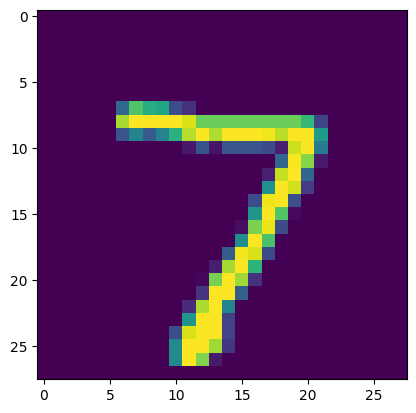

In [145]:
# First Data point in X test
plt.imshow(X_test[0])

In [146]:
print(Y_test[0])

7


In [147]:
Y_pred.shape # All 10k images and labels are stored

(10000, 10)

In [148]:
Y_pred = model.predict(X_test) # gives probabilities for all labels
Y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[9.72340430e-08, 1.15948314e-04, 3.38540405e-01, ...,
        1.00000000e+00, 1.37073069e-03, 4.82641399e-01],
       [3.02198515e-07, 9.99943197e-01, 1.00000000e+00, ...,
        9.59142739e-08, 9.98614907e-01, 4.13288508e-15],
       [6.89494300e-07, 9.99999762e-01, 7.76682138e-01, ...,
        3.49771172e-01, 3.44698466e-02, 5.83365978e-09],
       ...,
       [2.21068888e-12, 5.06367087e-06, 3.72083696e-06, ...,
        9.38212812e-01, 7.77097881e-01, 9.94609714e-01],
       [1.04313981e-10, 7.56086649e-07, 1.78659598e-09, ...,
        1.08434724e-05, 9.99999702e-01, 1.18274252e-10],
       [2.25528856e-06, 1.56387032e-05, 1.42519543e-08, ...,
        1.09226059e-14, 5.14805724e-04, 1.21556975e-12]], dtype=float32)

In [149]:
print(Y_pred[0].argmax())

7


In [150]:
# Get highest probability for all 10k images
print(Y_pred.argmax(axis=1))

[7 2 1 ... 4 5 6]


In [151]:
# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred.argmax(axis=1))
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 965,    0,    0,    1,    1,    0,    5,    3,    4,    1],
       [   0, 1127,    1,    1,    0,    0,    2,    0,    4,    0],
       [   2,    3, 1007,    3,    0,    0,    5,    3,    9,    0],
       [   0,    0,    6,  990,    0,    2,    0,    4,    6,    2],
       [   0,    2,    2,    1,  953,    1,    8,    2,    6,    7],
       [   2,    0,    0,   19,    2,  858,    8,    1,    2,    0],
       [   1,    2,    3,    1,    2,    8,  938,    0,    3,    0],
       [   0,    2,   10,    4,    1,    0,    0, 1007,    2,    2],
       [   0,    0,    2,    3,    3,    4,    2,    3,  956,    1],
       [   2,    4,    0,    9,    5,    4,    1,   11,    8,  965]],
      dtype=int32)>

Text(0.5, 47.7222222222222, 'Predicted Labels')

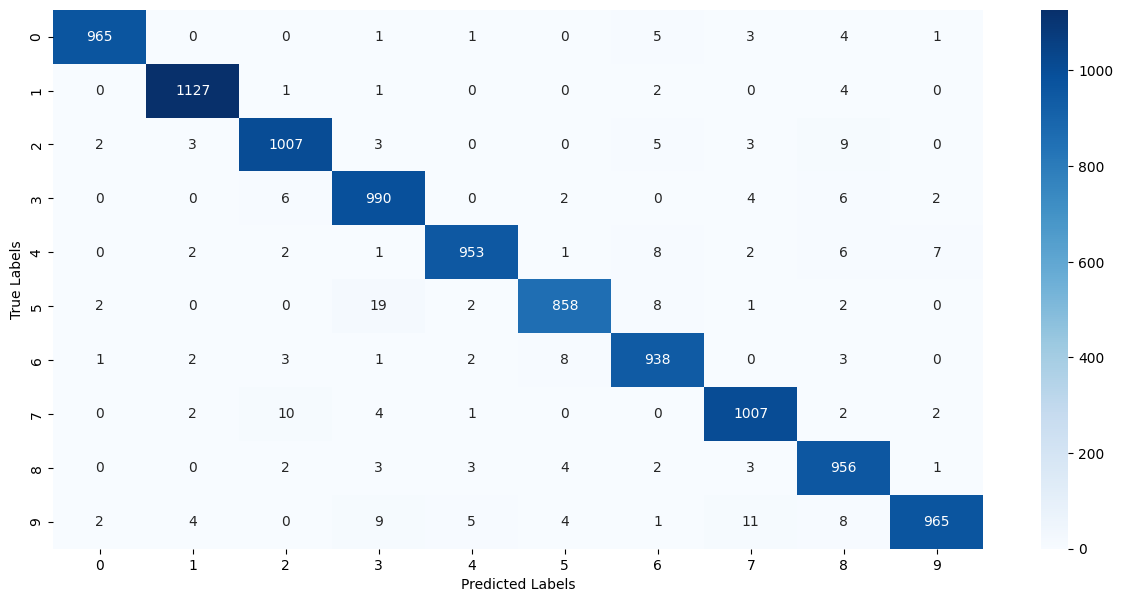

In [152]:
plt.figure(figsize = (15, 7))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues') # fmt = d -> all values int
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

Diagnol represents correctly predicted values of same labels

In [170]:
# Build Predictive System

def predict_digit(img_path):

    # Convert to Numpy Array
    img_np = cv2.imread(img_path)

    # Convert the image to grayscale
    img_gray = cv2.cvtColor(img_np, cv2.COLOR_BGR2GRAY)

    # resize the image to 28 x 28 dimensions
    img = cv2.resize(img_gray, (28, 28))

    # Scale the image
    img = img/255

    # Reshape the image
    # Inform the model that we are prediciting only for 1 image
    # 1 image of 28 x 28 dimension
    img_reshape = np.reshape(img, [1, 28, 28])

    # Predict the image label
    img_pred = model.predict(img_reshape)

    # Print the predicted label
    print("Label: ", img_pred.argmax())

    cv2_imshow(img_np)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Label:  6


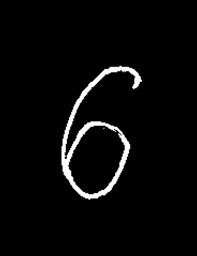

In [171]:
predict_digit('/content/mnist 2.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Label:  7


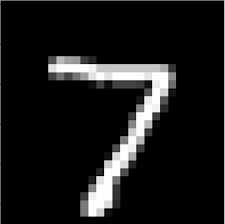

In [172]:
predict_digit('/content/mnist 3.png')

In [173]:
# Predictive System that takes user input


def predict_user_digit():

    img_path = input("Enter the path of the image: ")

    # Convert to Numpy Array
    img_np = cv2.imread(img_path)

    # Convert the image to grayscale
    img_gray = cv2.cvtColor(img_np, cv2.COLOR_BGR2GRAY)

    # resize the image to 28 x 28 dimensions
    img = cv2.resize(img_gray, (28, 28))

    # Scale the image
    img = img/255

    # Reshape the image
    # Inform the model that we are prediciting only for 1 image
    # 1 image of 28 x 28 dimension
    img_reshape = np.reshape(img, [1, 28, 28])

    # Predict the image label
    img_pred = model.predict(img_reshape)

    # Print the predicted label
    print("Label: ", img_pred.argmax())

    cv2_imshow(img_np)

Enter the path of the image: /content/mnist 4.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Label:  3


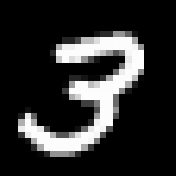

In [174]:
predict_user_digit()